# 01 - Data Exploration

This notebook looks at our assigned data before modeling. We focus on three ACORN segments (E, F and Q), their daily demand levels, the shape of a typical day, and how weather changes consumption. The point here is to understand what the model needs to learn. If the same pattern appears in the plots, it should later become a feature or a validation check.


## Setup

We import the project loading functions and the plotting libraries. The notebook reads the processed data created by the pipeline, so it uses the same inputs as the modeling scripts.


In [30]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from group5_energy.config import ACORN_GROUPS
from group5_energy.pipeline import load_daily_history, load_half_hourly_history, load_daily_weather

sns.set_theme(style="whitegrid")

try:
    from IPython.display import display
except ImportError:
    display = None


def show_plot(fig):
    if display is not None:
        display(fig)
    plt.close(fig)


## Loading the Data

First we load the daily consumption, half hourly consumption, and daily weather tables. This is just a quick check that we are studying the expected history before the forecast period.


In [31]:
daily = load_daily_history()
half = load_half_hourly_history()
weather = load_daily_weather()

print("Daily rows:", daily.shape)
print("Half-hourly rows:", half.shape)
print("ACORN groups:", ACORN_GROUPS)
print("Daily date range:", daily["Date"].min(), "to", daily["Date"].max())
print("Half-hourly date range:", half["DateTime"].min(), "to", half["DateTime"].max())

Daily rows: (1683, 5)
Half-hourly rows: (80796, 6)
ACORN groups: {'ACORN-E': 'Affluent', 'ACORN-F': 'Comfortable', 'ACORN-Q': 'Adversity'}
Daily date range: 2012-07-01 00:00:00 to 2014-01-12 00:00:00
Half-hourly date range: 2012-06-30 22:00:00 to 2014-01-12 23:30:00


Here we are checking the modeling data, not changing the raw client files. The irregularity notebook explains the earlier cleaning choices in more detail.


## Consumption level by segment

Before looking at curves, we compare simple daily statistics by segment. This gives a useful baseline for interpreting all later plots.


In [32]:
daily.groupby("Acorn")["Conso_kWh"].agg(["count", "mean", "min", "max"]).round(3)

,count,mean,min,max
Acorn,,,,
ACORN-E,561,10.248,7.087,16.050
ACORN-F,561,9.207,7.147,13.495
ACORN-Q,561,7.515,6.118,10.350


ACORN-E has the highest average daily consumption, ACORN-F is in the middle, and ACORN-Q is the lowest. This ranking is stable enough that the models should not treat the three groups as interchangeable.

The minimum and maximum values also show that there is meaningful variation within each group. A constant segment average would be too weak for forecasting.


## Daily seasonality

The next plot smooths daily consumption with a 14 day rolling mean. Smoothing removes some day to day noise so we can see the broader seasonal movement.


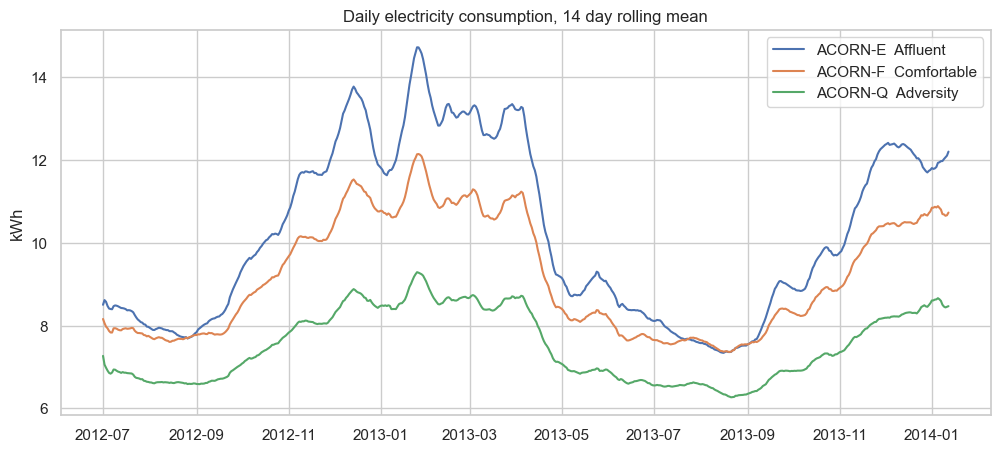

In [33]:
fig, ax = plt.subplots(figsize=(12, 5))
for acorn, group in daily.sort_values("Date").groupby("Acorn"):
    rolling = group.set_index("Date")["Conso_kWh"].rolling(14, min_periods=1).mean()
    ax.plot(rolling.index, rolling.values, label=f"{acorn}  {ACORN_GROUPS[acorn]}")
ax.set_title("Daily electricity consumption, 14 day rolling mean")
ax.set_ylabel("kWh")
ax.legend()
show_plot(fig)

The lines show a clear winter pattern. Consumption rises during colder periods and falls during warmer periods.

The three ACORN segments move in a similar direction over time, but at different levels. This supports using shared calendar and weather features while still keeping the acorn segment as an important feature.


## Shape during a day

For the short term forecast, the half hourly data is very important. We average consumption by half hour slot to see what a normal day looks like for each segment.

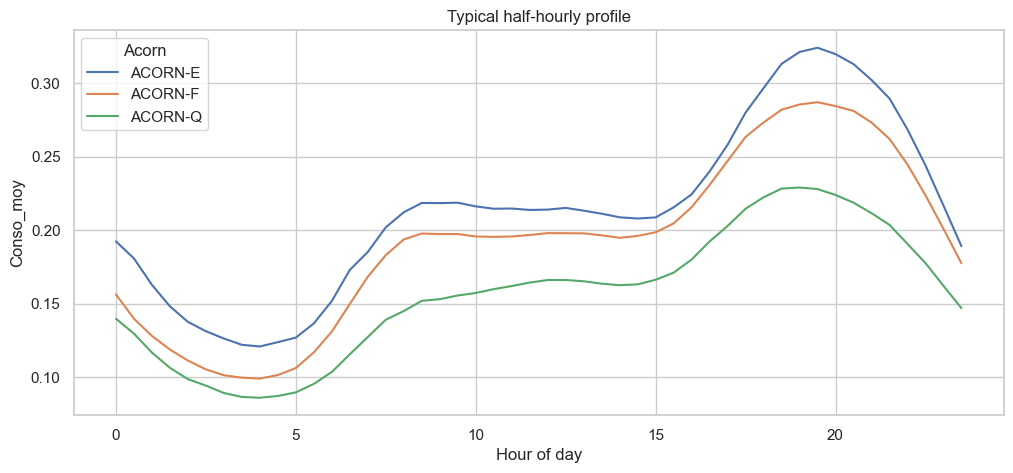

In [34]:
profile = half.copy()
profile["half_hour_slot"] = profile["DateTime"].dt.hour*2 + (profile["DateTime"].dt.minute//30)
profile = profile.groupby(["Acorn", "half_hour_slot"], as_index=False)["Conso_moy"].mean()
profile["time_of_day"] = profile["half_hour_slot"] / 2

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=profile, x="time_of_day", y="Conso_moy", hue="Acorn", ax=ax)
ax.set_title("Typical half-hourly profile")
ax.set_xlabel("Hour of day")
show_plot(fig)

The average day has lower demand overnight and higher demand later in the day. Also, during the evening we observe a peak. 

This is why the short term model includes half hour slot, hour, weekday, lag, and rolling features. The model needs to know both the time of day and the recent consumption level.


## Temperature relationship

Lastly, we compute the correlation between daily consumption and temperature (by segment). This is a simple way to test whether weather should be included in the model.


In [35]:
daily_weather = daily.merge(weather[["Date", "temperatureMean"]], on="Date", how="left")
daily_weather.groupby("Acorn").apply(
    lambda group: group["Conso_kWh"].corr(group["temperatureMean"]),
    include_groups=False,
).rename("temperature_consumption_corr").round(3)

Acorn
ACORN-E   -0.916
ACORN-F   -0.885
ACORN-Q   -0.868
Name: temperature_consumption_corr, dtype: float64

The correlations are strongly negative for all three segments. When the mean temperature is lower, electricity consumption is higher.

This does not prove causality by itself, but it is consistent with winter heating behavior and gives a clear reason to keep temperature features in both the daily and half hourly models.
